In [1]:
import scanpy as sc

# Load the first patient's data
adata = sc.read_10x_mtx(
    'sample_APOE3',  # The directory containing the 3 files
    var_names='gene_symbols',
    cache=True
)

# Print the object to see the number of cells and genes!
print(adata)

AnnData object with n_obs × n_vars = 10526 × 36601
    var: 'gene_ids', 'feature_types'


In [2]:
import scanpy as sc

# Load the first Alzheimer's patient data (APOE3)
adata = sc.read_10x_mtx(
    'sample_APOE3',  # Yahan apne us folder ka naam likhein jisme 3 files hain
    var_names='gene_symbols',
    cache=True
)

# Check the shape of the data
print(adata)

AnnData object with n_obs × n_vars = 10526 × 36601
    var: 'gene_ids', 'feature_types'


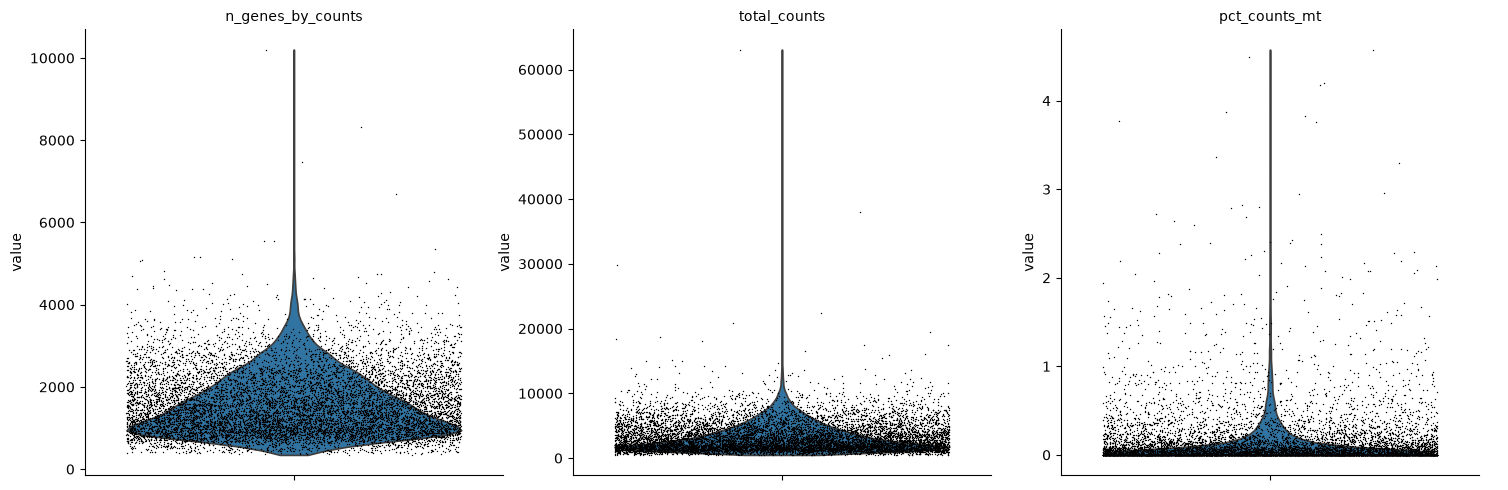

In [3]:
# 1. Find all mitochondrial genes (they start with 'MT-')
adata.var['mt'] = adata.var_names.str.startswith('MT-')

# 2. Calculate QC metrics using Scanpy
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# 3. Visualize the quality using a Violin Plot
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

In [4]:
# 1. Remove empty droplets (cells with less than 200 genes)
sc.pp.filter_cells(adata, min_genes=200)

# 2. Remove doublets (cells with an abnormally high number of genes)
adata = adata[adata.obs.n_genes_by_counts < 4500, :]

# 3. Remove dying cells (cells with more than 5% mitochondrial RNA)
adata = adata[adata.obs.pct_counts_mt < 5, :]

# Print the object to see how many high-quality cells survived our filter!
print(adata)

View of AnnData object with n_obs × n_vars = 10501 × 36601
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'


/home/azharimam/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/azharimam/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/azharimam/miniforge3/envs/scanpy_env/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


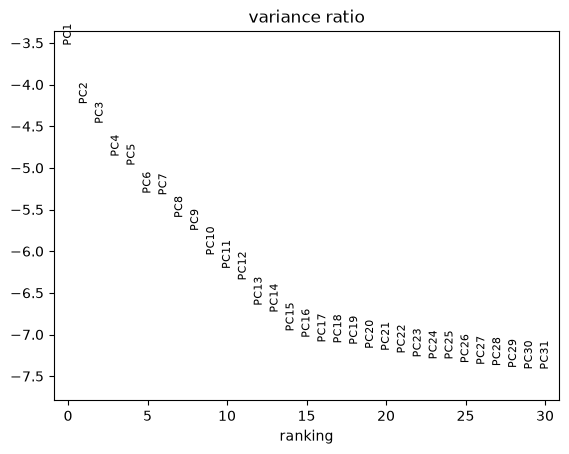

In [5]:
# 1. Normalize total counts (equalize RNA across all cells)
sc.pp.normalize_total(adata, target_sum=1e4)

# 2. Log transform (compress extreme values for smoother data)
sc.pp.log1p(adata)

# 3. Identify Highly Variable Genes (find the most important genes)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

# Keep only those highly variable genes for next steps
adata = adata[:, adata.var.highly_variable]

# 4. Scale the data (give equal weight to all genes)
sc.pp.scale(adata, max_value=10)

# 5. Run PCA (reduce complexity / dimensions)
sc.tl.pca(adata, svd_solver='arpack')

# 6. Plot the PCA variance to see how much data is captured
sc.pl.pca_variance_ratio(adata, log=True)

/tmp/ipykernel_22137/705220207.py:6: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


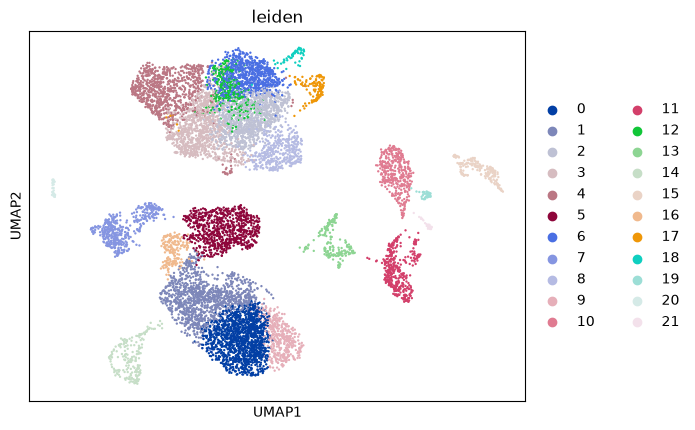

In [6]:
# 1. Compute the neighborhood graph (Find which cells are similar to each other)
# Hum yahan n_pcs=20 use kar rahe hain kyunki hamare graph ka 'elbow' wahan tak flat ho gaya tha
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=20)

# 2. Cluster the cells using the Leiden algorithm (Group similar cells into "neighborhoods")
sc.tl.leiden(adata)

# 3. Compute UMAP (Compress the data into 2D so we can look at it on a flat screen)
sc.tl.umap(adata)

# 4. Plot the final UMAP and color it by the clusters!
sc.pl.umap(adata, color=['leiden'])

/home/azharimam/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/azharimam/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/azharimam/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/azharimam/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/azharimam/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid 

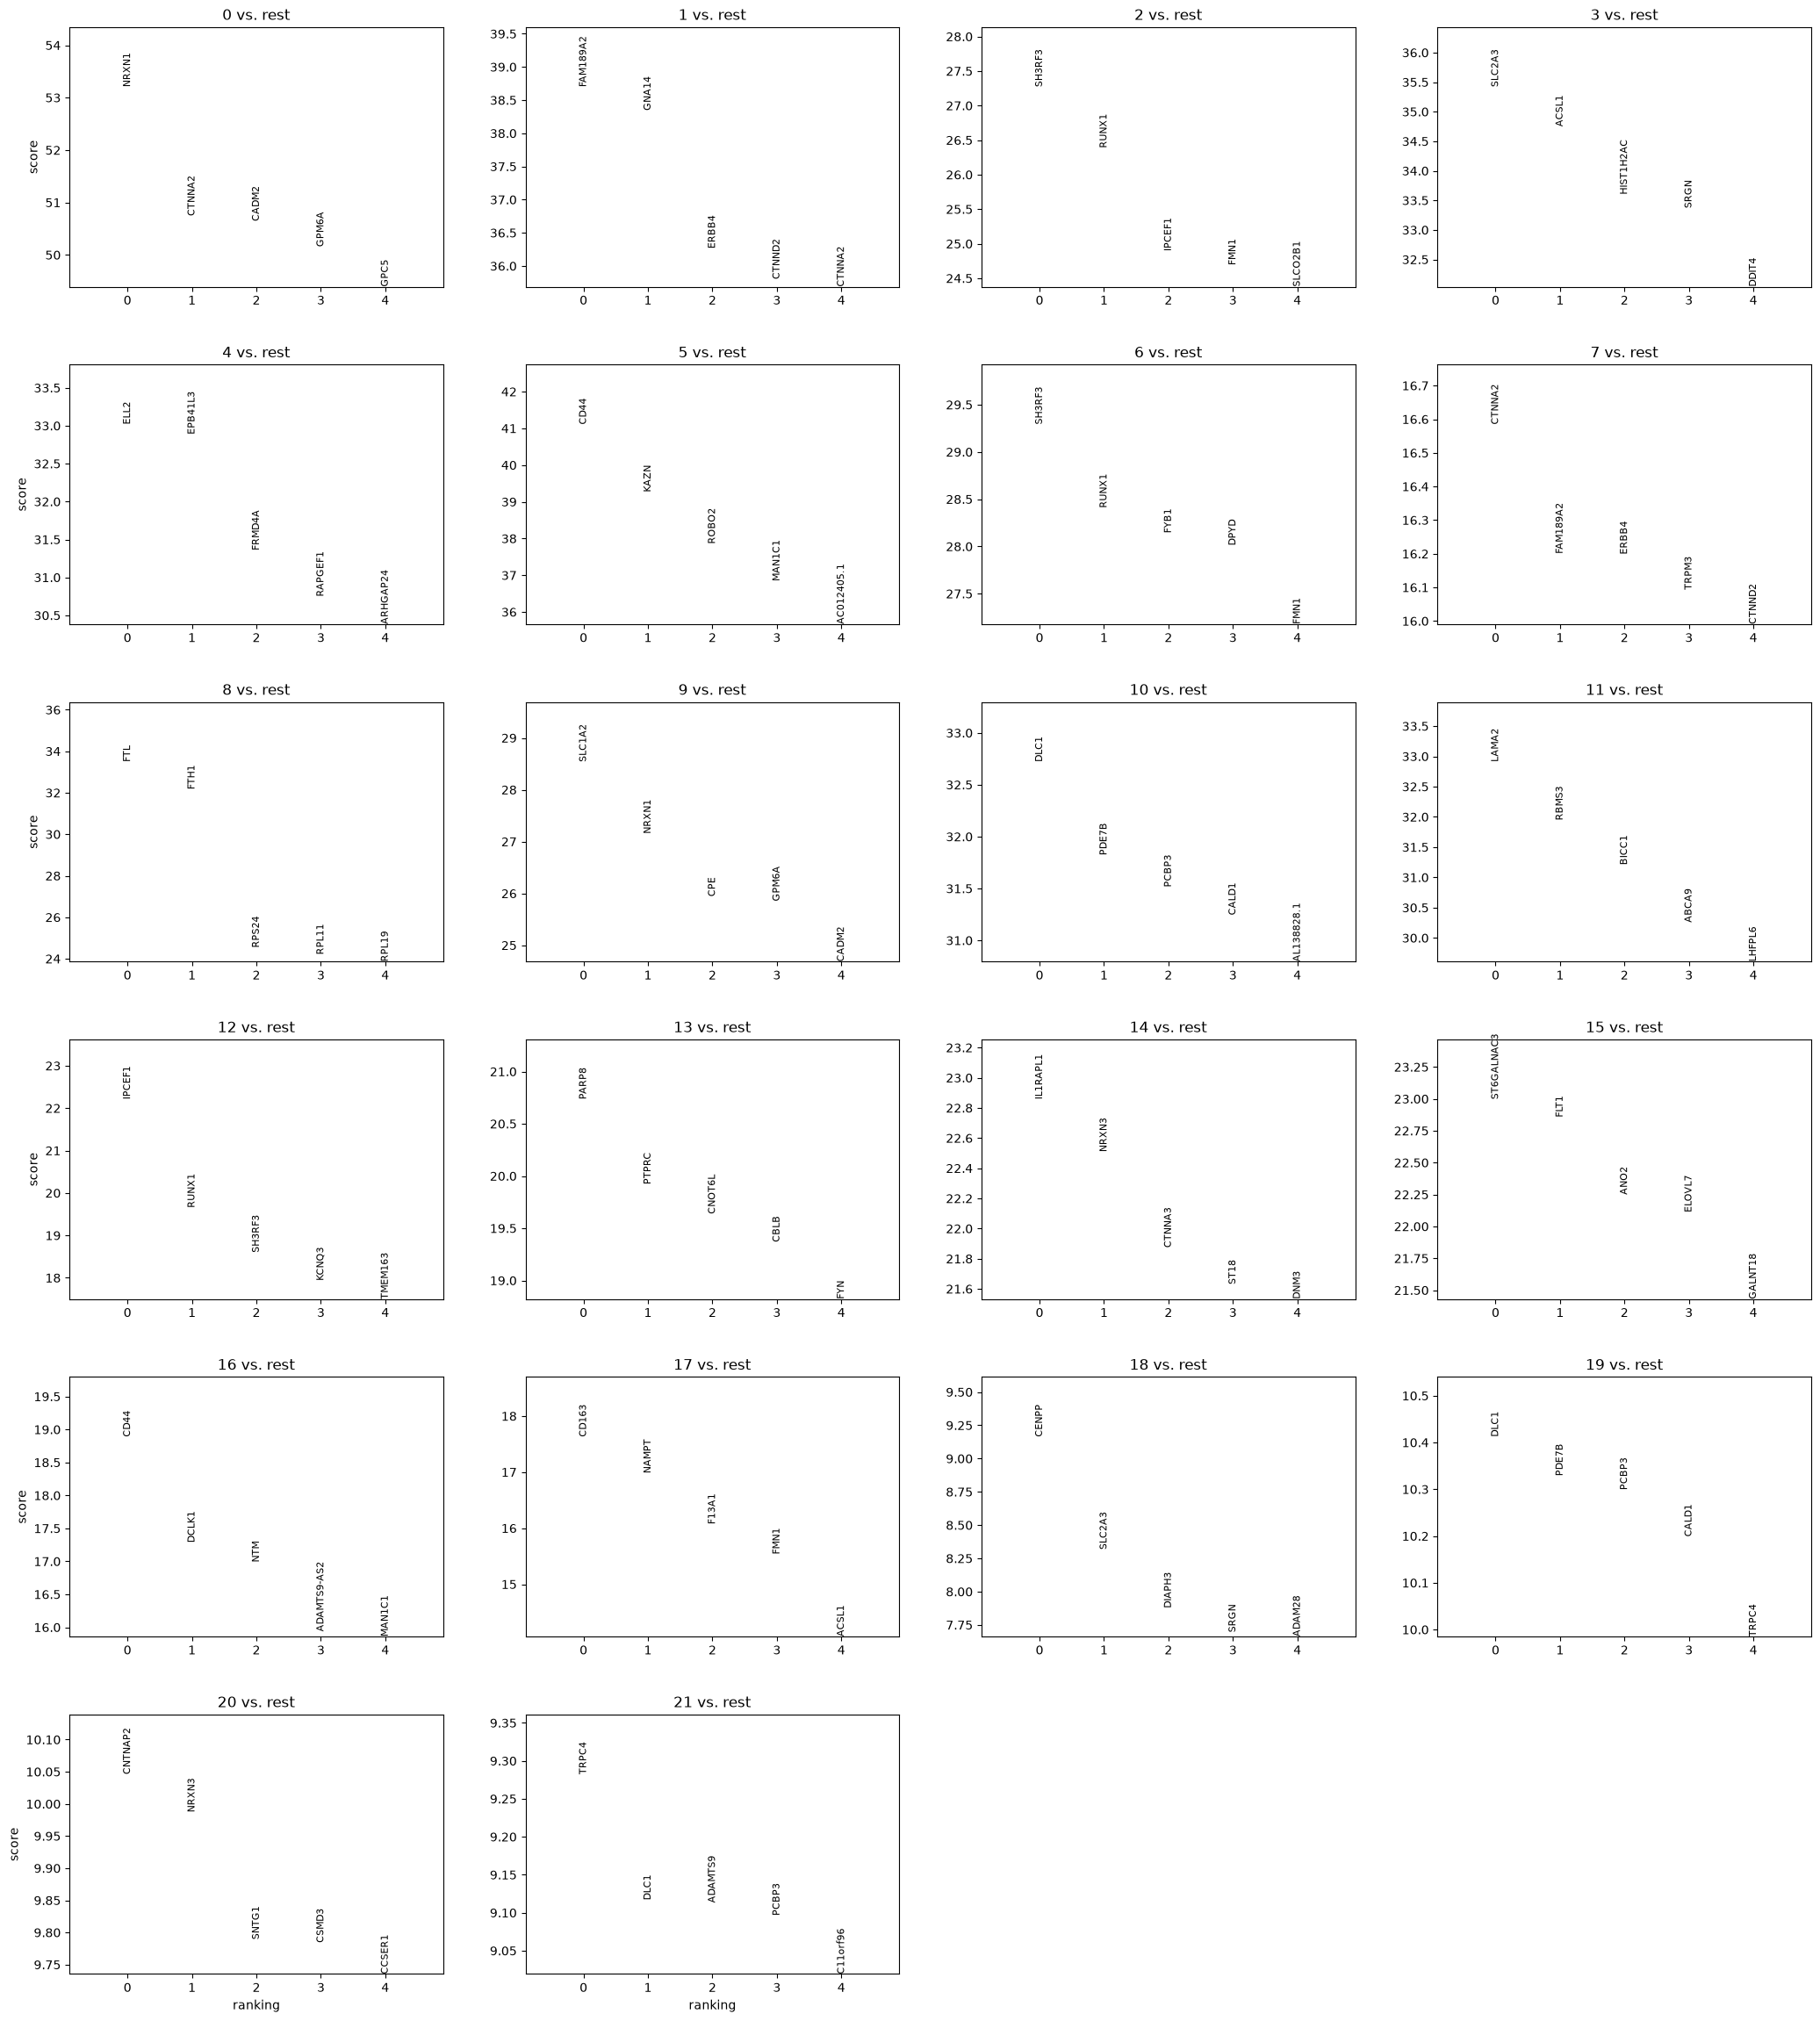

In [7]:
# 1. Find the unique marker genes for every single cluster
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

# 2. Plot the top 5 marker genes for each cluster
sc.pl.rank_genes_groups(adata, n_genes=5, sharey=False)

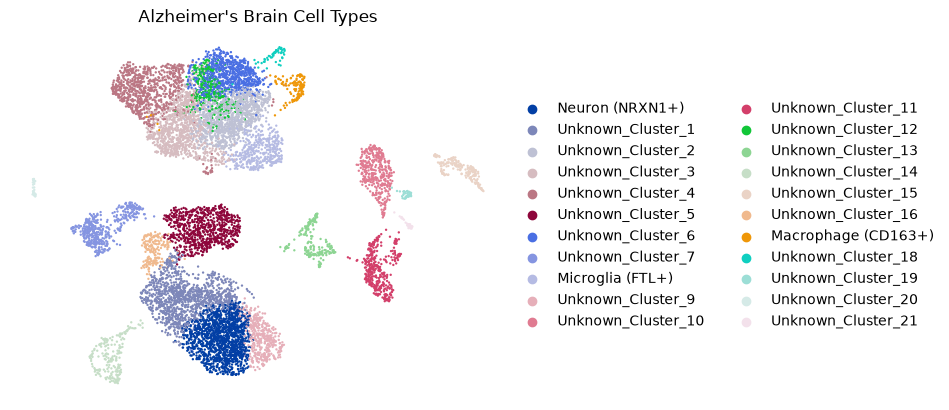

In [8]:
# 1. Create a dictionary (mapping numbers to real biological names)
# Dhyan rahe, Scanpy cluster numbers ko 'text' (string) ki tarah read karta hai, isliye hum '0' likh rahe hain
cell_type_mapping = {
    '0': 'Neuron (NRXN1+)',
    '8': 'Microglia (FTL+)',
    '17': 'Macrophage (CD163+)'
}

# 2. Create a new column in our data called 'cell_type'
# Yeh code dictionary check karega. Agar naam mila toh theek, warna 'Unknown' likh dega.
adata.obs['cell_type'] = adata.obs['leiden'].map(
    lambda cluster_id: cell_type_mapping.get(cluster_id, f"Unknown_Cluster_{cluster_id}")
)

# 3. Plot the final publication-ready UMAP!
sc.pl.umap(adata, color=['cell_type'], frameon=False, title="Alzheimer's Brain Cell Types")

In [9]:
# Save the fully processed AnnData object to an h5ad file
adata.write('sample_APOE3_processed.h5ad')

print("Data successfully saved!")

Data successfully saved!
